Importação das bibliotecas:

In [20]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from io import StringIO

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")

Carregar a base:

In [21]:
url = "https://ourworldindata.org/grapher/share-of-adults-who-smoke.csv?csvType=full&useColumnShortNames=false&v=1"

resposta = requests.get(url, verify=False)
resposta.raise_for_status()

df = pd.read_csv(StringIO(resposta.text))
df.head()

,Entity,Code,Year,Share of adults who smoke or use tobacco (age-standardized)
0,Afghanistan,AFG,2000,39.2
1,Afghanistan,AFG,2005,34.2
2,Afghanistan,AFG,2007,32.5
3,Afghanistan,AFG,2010,30.2
4,Afghanistan,AFG,2015,26.6


In [22]:
# Conferindo os nomes reais das colunas
df.columns.tolist()

['Entity',
 'Code',
 'Year',
 'Share of adults who smoke or use tobacco (age-standardized)']

Preparação dos dados:

In [23]:
# Renomeia apenas as colunas que sempre aparecem
df = df.rename(columns={
    "Entity": "pais",
    "Code": "codigo_pais",
    "Year": "ano"
})

# Identifica automaticamente a coluna de prevalência
colunas_fixas = ["pais", "codigo_pais", "ano"]
possiveis_colunas_valor = [col for col in df.columns if col not in colunas_fixas]

print("Possíveis colunas de valor encontradas:")
print(possiveis_colunas_valor)

# Usa a primeira coluna numérica disponível como prevalência
coluna_prevalencia = None

for col in possiveis_colunas_valor:
    teste = pd.to_numeric(df[col], errors="coerce")
    if teste.notna().sum() > 0:
        coluna_prevalencia = col
        break

print("Coluna usada como prevalência:", coluna_prevalencia)

df = df.rename(columns={coluna_prevalencia: "prevalencia"})

df = df[["pais", "codigo_pais", "ano", "prevalencia"]].copy()

df["ano"] = pd.to_numeric(df["ano"], errors="coerce")
df["prevalencia"] = pd.to_numeric(df["prevalencia"], errors="coerce")

df = df.dropna(subset=["pais", "codigo_pais", "ano", "prevalencia"])

# Mantém apenas países com código ISO de 3 letras
df = df[df["codigo_pais"].astype(str).str.len() == 3].copy()

df.head()

Possíveis colunas de valor encontradas:
['Share of adults who smoke or use tobacco (age-standardized)']
Coluna usada como prevalência: Share of adults who smoke or use tobacco (age-standardized)


,pais,codigo_pais,ano,prevalencia
0,Afghanistan,AFG,2000,39.2
1,Afghanistan,AFG,2005,34.2
2,Afghanistan,AFG,2007,32.5
3,Afghanistan,AFG,2010,30.2
4,Afghanistan,AFG,2015,26.6


In [24]:
def classificar_prevalencia(valor):
    if valor <= 10:
        return "baixa"
    elif valor <= 20:
        return "media"
    else:
        return "alta"

df["classe_prevalencia"] = df["prevalencia"].apply(classificar_prevalencia)

df["classe_prevalencia"].value_counts()

classe_prevalencia
alta     800
media    379
baixa    141
Name: count, dtype: int64

Codificação das variáveis:

In [25]:
le_pais = LabelEncoder()
df["pais_cod"] = le_pais.fit_transform(df["pais"])

X = df[["pais_cod", "ano"]]
y = df["classe_prevalencia"]

X.head()

,pais_cod,ano
0,0,2000
1,0,2005
2,0,2007
3,0,2010
4,0,2015


Divisão entre treino e teste:

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Tamanho do treino:", X_train.shape)
print("Tamanho do teste:", X_test.shape)

Tamanho do treino: (1056, 2)
Tamanho do teste: (264, 2)


Aplicação do método analítico - Árvore de Decisão:

In [27]:
modelo = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

Medidas de acurácia:

In [28]:
acuracia = accuracy_score(y_test, y_pred)

print("Acurácia:", round(acuracia, 4))

Acurácia: 0.625


In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        alta       0.65      0.91      0.76       160
       baixa       0.67      0.07      0.13        28
       media       0.49      0.22      0.31        76

    accuracy                           0.62       264
   macro avg       0.60      0.40      0.40       264
weighted avg       0.60      0.62      0.56       264



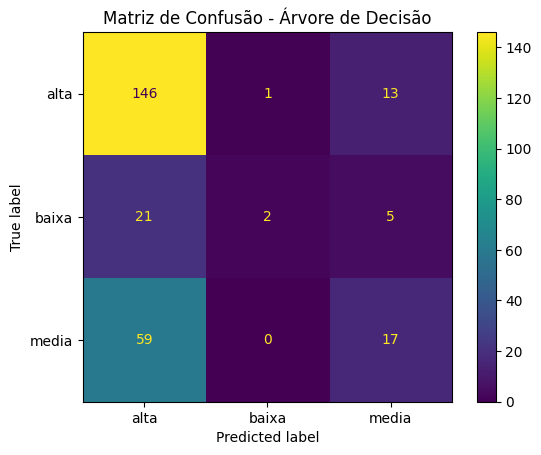

In [30]:
matriz = confusion_matrix(y_test, y_pred, labels=modelo.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=modelo.classes_)
disp.plot()
plt.title("Matriz de Confusão - Árvore de Decisão")
plt.show()

Gráficos de apoio ao storytelling:

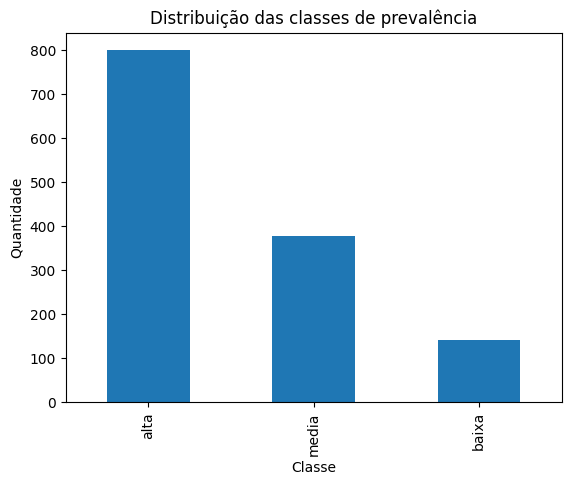

In [31]:
df["classe_prevalencia"].value_counts().plot(kind="bar")
plt.title("Distribuição das classes de prevalência")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

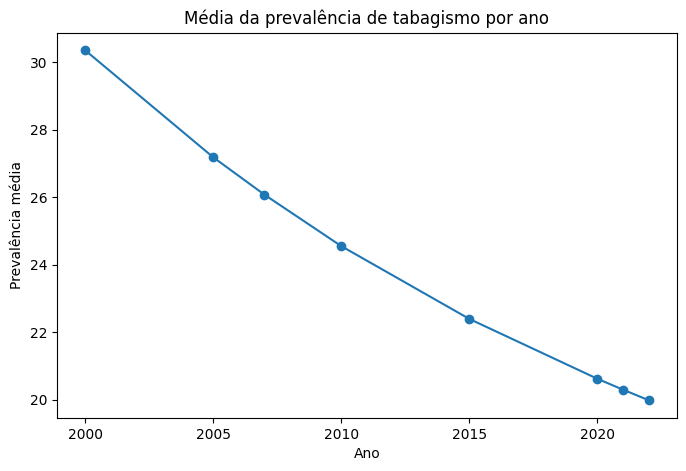

In [32]:
media_ano = df.groupby("ano")["prevalencia"].mean()

plt.figure(figsize=(8,5))
plt.plot(media_ano.index, media_ano.values, marker="o")
plt.title("Média da prevalência de tabagismo por ano")
plt.xlabel("Ano")
plt.ylabel("Prevalência média")
plt.show()

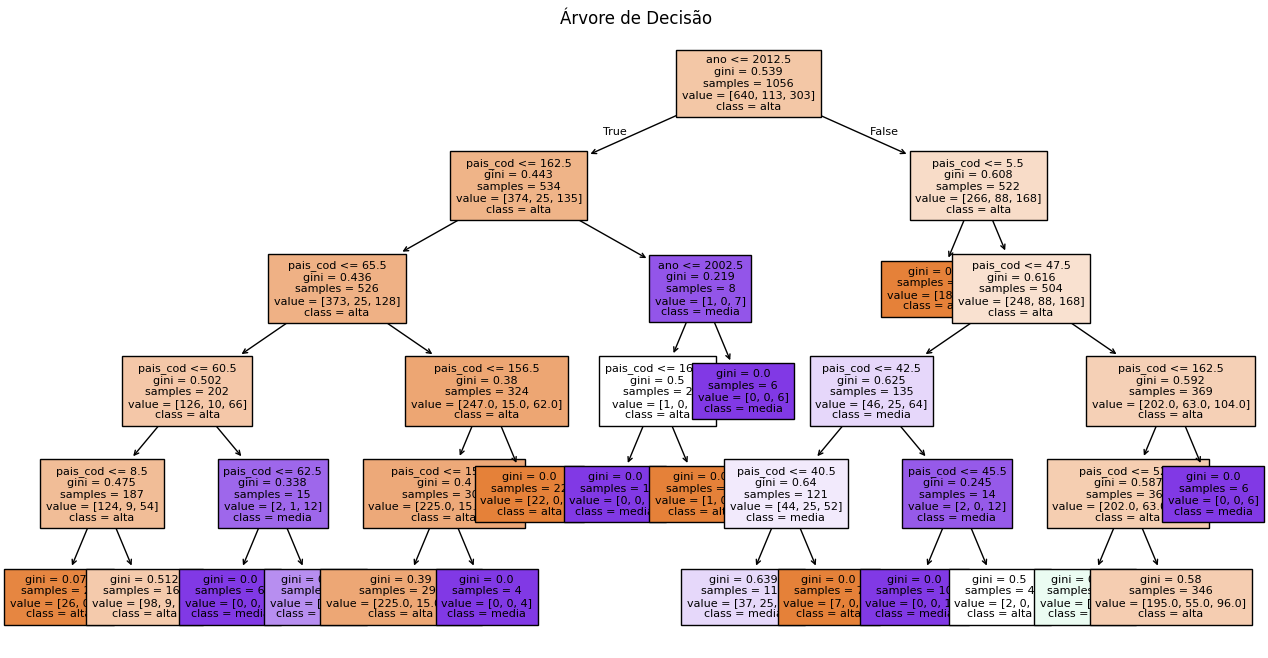

In [33]:
plt.figure(figsize=(16,8))
plot_tree(
    modelo,
    feature_names=X.columns,
    class_names=modelo.classes_,
    filled=True,
    fontsize=8
)
plt.title("Árvore de Decisão")
plt.show()

Relatório:

In [34]:
print("Resumo da Etapa 3")
print("-------------------")
print("Total de registros utilizados:", len(df))
print("Quantidade de países:", df["pais"].nunique())
print("Período analisado:", int(df["ano"].min()), "a", int(df["ano"].max()))
print("Acurácia obtida:", round(acuracia, 4))

Resumo da Etapa 3
-------------------
Total de registros utilizados: 1320
Quantidade de países: 165
Período analisado: 2000 a 2022
Acurácia obtida: 0.625
